# 02 · Per-task test MAE, per backbone

**How does each method do on each individual property?**

At 11 tasks the MAEs span four orders of magnitude (zpve ≈ 0.005 eV,
U₀ ≈ 10 eV), so a shared y-axis would hide everything small — hence small
multiples with a per-panel axis. At 2 tasks the scales are comparable and
grouped bars work.

STL is a reference line rather than a fifth bar, which keeps the palette to four
validated slots.

In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, ".")
import numpy as np, matplotlib.pyplot as plt
import common as C
C.apply_style()
print("results trees:")
for b, d in C.RESULTS.items():
    for tag, p in d.items():
        print(f"  {b:9s} {tag:7s} {'OK ' if p.is_dir() else 'MISSING'} {p}")

results trees:
  Uni-Mol   2task   OK  E:\Projects\Results\Unimol\results_2task
  Uni-Mol   11task  OK  E:\Projects\Results\Unimol\results_11task
  GNN       2task   OK  E:\Projects\Results\GNN\result_2task
  GNN       11task  OK  E:\Projects\Results\GNN\result_11task


In [2]:
TAG = "11task"           # "2task" or "11task"
BACKBONE = "Uni-Mol"     # "Uni-Mol" or "GNN"

d = C.load_runs(BACKBONE, TAG)
labels = [m for m in C.METHODS if m in d["mtl"]]
tasks = d["tasks"]
print(BACKBONE, TAG, "|", len(tasks), "tasks |", ", ".join(labels))

Uni-Mol 11task | 11 tasks | LS, PCGrad, AIM-Scalar, AIM-Matrix


saved E:\Projects\aim_mtl\notebooks\figures\11task\per_task_mae_UniMol_11task.png


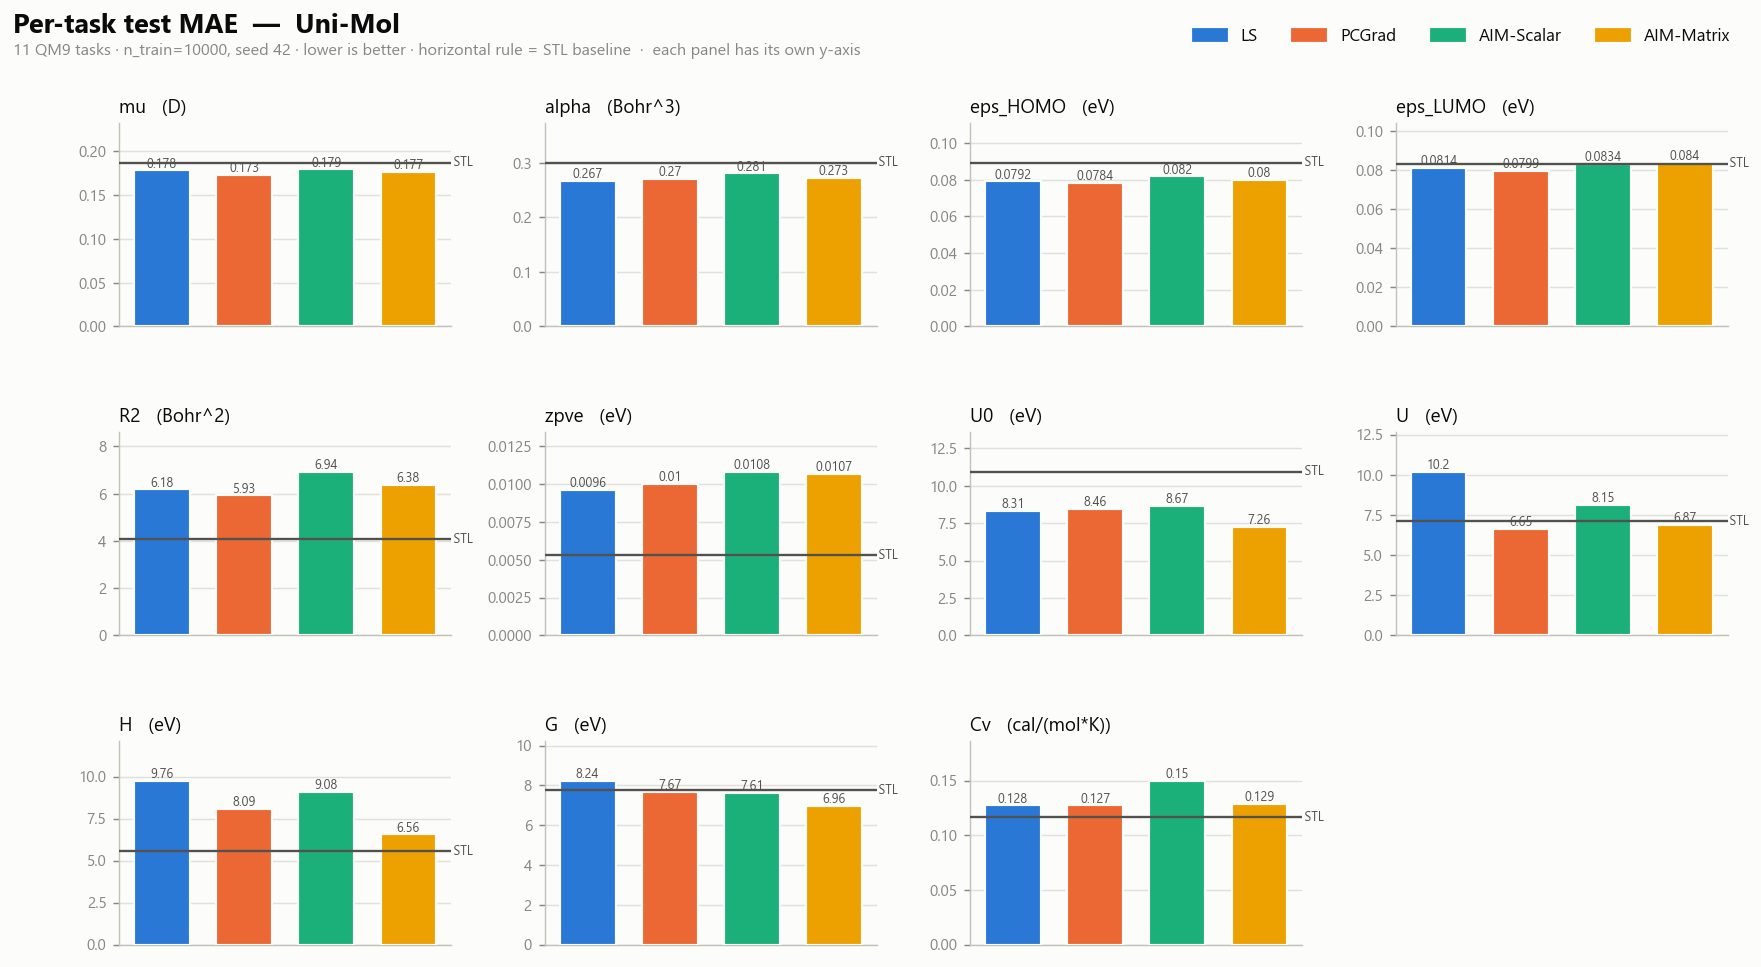

In [3]:
def per_task_figure(d, labels, backbone):
    tasks = d["tasks"]; n = len(tasks)
    if n <= 3:
        fig, ax = plt.subplots(figsize=(3.2 + 2.1 * n, 4.6))
        x = np.arange(n); w = .8 / len(labels)
        for s, l in enumerate(labels):
            vals = [d["mtl"][l].get(t, np.nan) for t in tasks]
            off = (s - (len(labels) - 1) / 2) * w
            ax.bar(x + off, vals, w * .9, color=C.METHOD_COLOUR[s],
                   edgecolor=C.SURFACE, linewidth=1.2, zorder=3, label=l)
            for xi, v in zip(x + off, vals):
                ax.text(xi, v, f"{v:.3f}", ha="center", va="bottom",
                        fontsize=7, color=C.SECONDARY, rotation=90)
        for i, t in enumerate(tasks):
            if t in d["stl"]:
                ax.plot([i - .45, i + .45], [d["stl"][t]] * 2, color=C.SECONDARY, lw=1.4, zorder=5)
        ax.set_xticks(x, [f"{t}\n({C.TASK_UNITS.get(t,'')})" for t in tasks])
        ax.set_ylabel("test MAE (physical units)"); ax.margins(y=.22)
        for s in ("top", "right"): ax.spines[s].set_visible(False)
        ax.grid(True, axis="y", zorder=0); ax.set_axisbelow(True)
        ax.legend(loc="upper center", ncol=len(labels)); top = .80
    else:
        ncol = 4; nrow = int(np.ceil(n / ncol))
        fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 2.7 * nrow))
        axes = np.atleast_1d(axes).ravel()
        for ax, t in zip(axes, tasks):
            vals = [d["mtl"][l].get(t, np.nan) for l in labels]
            ax.bar(np.arange(len(labels)), vals, .68,
                   color=C.METHOD_COLOUR[:len(labels)], edgecolor=C.SURFACE,
                   linewidth=1.2, zorder=3)
            for xi, v in enumerate(vals):
                ax.text(xi, v, f"{v:.3g}", ha="center", va="bottom",
                        fontsize=7, color=C.SECONDARY)
            if t in d["stl"]:
                ax.axhline(d["stl"][t], color=C.SECONDARY, lw=1.3, zorder=5)
                ax.text(len(labels) - .5, d["stl"][t], " STL", va="center",
                        ha="left", fontsize=7, color=C.SECONDARY)
            ax.set_xticks([]); ax.margins(y=.24)
            ax.set_title(f"{t}   ({C.TASK_UNITS.get(t,'')})", color=C.INK, loc="left", pad=6)
            for s in ("top", "right"): ax.spines[s].set_visible(False)
            ax.grid(True, axis="y", zorder=0); ax.set_axisbelow(True)
        for ax in axes[n:]: ax.set_axis_off()
        h = [plt.Rectangle((0, 0), 1, 1, color=C.METHOD_COLOUR[i]) for i in range(len(labels))]
        fig.legend(h, labels, loc="upper right", bbox_to_anchor=(.99, .985), ncol=len(labels))
        top = .88
    fig.suptitle(f"Per-task test MAE  —  {backbone}", x=.01, y=.985, ha="left",
                 fontsize=15, fontweight="bold", color=C.INK)
    fig.text(.01, .945 if n > 3 else .925,
             f"{n} QM9 tasks · n_train={C.N_TRAIN}, seed {C.SEED} · lower is better · "
             f"horizontal rule = STL baseline"
             + ("  ·  each panel has its own y-axis" if n > 3 else ""),
             fontsize=9, color=C.MUTED, ha="left")
    fig.subplots_adjust(left=.07, right=.98, top=top, bottom=.10, hspace=.52, wspace=.28)
    return fig

fig = per_task_figure(d, labels, BACKBONE)
C.save(fig, f"per_task_mae_{BACKBONE.replace('-','')}_{TAG}", TAG); plt.show()

### Both backbones in one go

In [4]:
for b in ("Uni-Mol", "GNN"):
    dd = C.load_runs(b, TAG)
    ll = [m for m in C.METHODS if m in dd["mtl"]]
    f = per_task_figure(dd, ll, b)
    C.save(f, f"per_task_mae_{b.replace('-','')}_{TAG}", TAG); plt.close(f)

saved E:\Projects\aim_mtl\notebooks\figures\11task\per_task_mae_UniMol_11task.png
saved E:\Projects\aim_mtl\notebooks\figures\11task\per_task_mae_GNN_11task.png
